In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import splitfolders
from tensorflow.keras.preprocessing.image import ImageDataGenerator 

In [ ]:
# old_data = 'C:\GitHub\Datathon2023\data\Driver Drowsiness Dataset (DDD)'
# split_data = 'C:\GitHub\Datathon2023\data\split_data'
# splitfolders.ratio(old_data, output=split_data, seed=42, ratio=(0.8, 0.125, 0.075), group_prefix=None)

<>:1: SyntaxWarning: invalid escape sequence '\G'
<>:2: SyntaxWarning: invalid escape sequence '\G'
<>:1: SyntaxWarning: invalid escape sequence '\G'
<>:2: SyntaxWarning: invalid escape sequence '\G'
C:\Users\stlso\AppData\Local\Temp\ipykernel_14920\3505057835.py:1: SyntaxWarning: invalid escape sequence '\G'
  old_data = 'C:\GitHub\Datathon2023\data\Driver Drowsiness Dataset (DDD)'
C:\Users\stlso\AppData\Local\Temp\ipykernel_14920\3505057835.py:2: SyntaxWarning: invalid escape sequence '\G'
  split_data = 'C:\GitHub\Datathon2023\data\split_data'


In [10]:
train_data = "../data/split_data/train"
test_data = "../data/split_data/test"
validation_data = "../data/split_data/val"

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
train_batches = train_datagen.flow_from_directory(
    train_data,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    shuffle=True
)

test_batches = test_datagen.flow_from_directory(
    test_data,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary' ,
    shuffle=True
)

val_batches = val_datagen.flow_from_directory(
    validation_data,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    shuffle=True
)

Found 33434 images belonging to 2 classes.
Found 3136 images belonging to 2 classes.
Found 5223 images belonging to 2 classes.


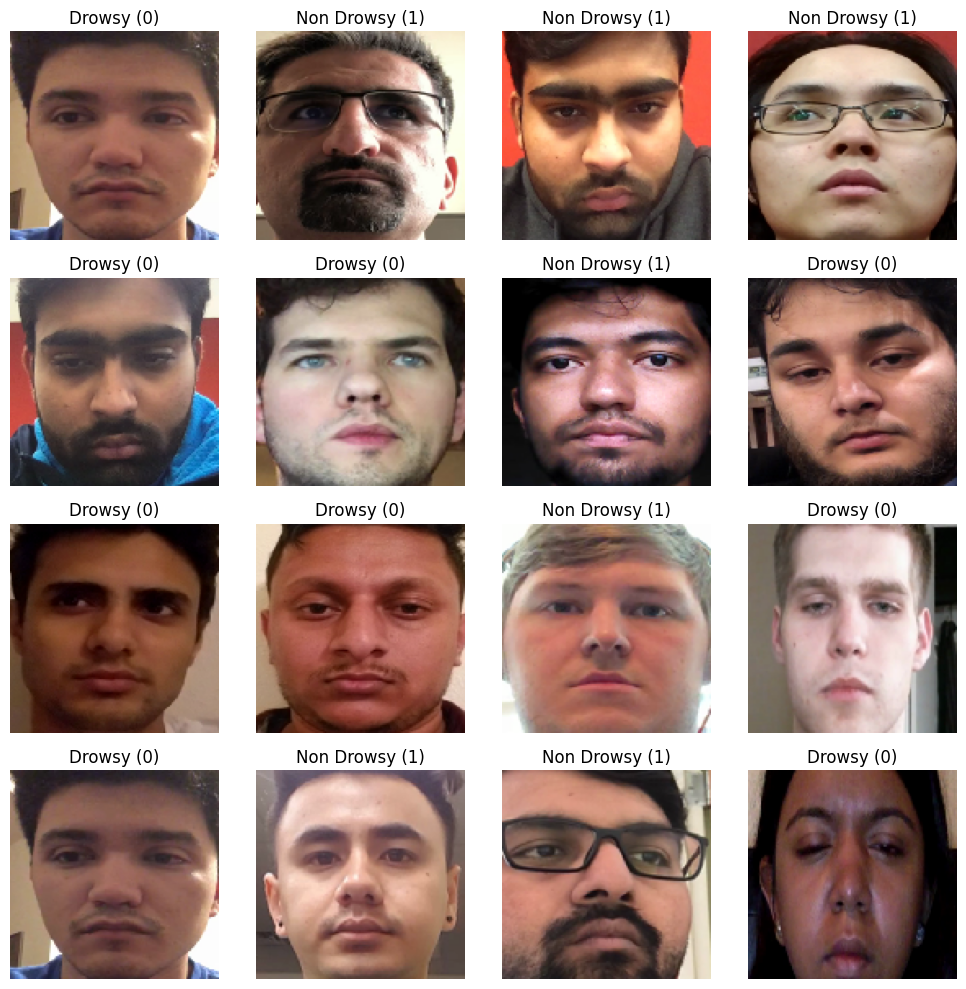

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
class_indices = train_batches.class_indices

for i in range(4):
    images, labels = next(train_batches)
    for j in range(4):
        
        ax = axes[i, j]
        ax.imshow(images[j])
        ax.axis('off')
        label = int(labels[j])  
        label_name = list(class_indices.keys())[list(class_indices.values()).index(label)]
        ax.set_title(f'{label_name} ({label})')

plt.tight_layout()
plt.show()

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.regularizers import l2

In [45]:
model = Sequential([
    Conv2D(8, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3), 
           kernel_regularizer=l2(0.01)),  # L2 regularization with lambda=0.01
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Conv2D(16, (3, 3), activation='relu', padding='same', 
           kernel_regularizer=l2(0.01)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same', 
           kernel_regularizer=l2(0.01)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    GlobalAveragePooling2D(),
    Dense(16, activation='relu', 
          kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 64, 64, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,801 (26.57 KB)

 Trainable params: 6,689 (26.13 KB)

 Non-trainable params: 112 (448.00 B)

In [46]:
history = model.fit(
    train_batches,
    validation_data=val_batches,
    epochs=10
)

Epoch 1/10
2090/2090 ━━━━━━━━━━━━━━━━━━━━ 86s 39ms/step - accuracy: 0.7032 - loss: 1.0305 - val_accuracy: 0.8769 - val_loss: 0.6435
Epoch 2/10
2090/2090 ━━━━━━━━━━━━━━━━━━━━ 85s 41ms/step - accuracy: 0.8734 - loss: 0.6166 - val_accuracy: 0.9621 - val_loss: 0.3765
Epoch 3/10
2090/2090 ━━━━━━━━━━━━━━━━━━━━ 149s 71ms/step - accuracy: 0.9464 - loss: 0.4028 - val_accuracy: 0.9791 - val_loss: 0.2684
Epoch 4/10
2090/2090 ━━━━━━━━━━━━━━━━━━━━ 203s 97ms/step - accuracy: 0.9629 - loss: 0.3073 - val_accuracy: 0.9904 - val_loss: 0.1991
Epoch 5/10
2090/2090 ━━━━━━━━━━━━━━━━━━━━ 108s 52ms/step - accuracy: 0.9715 - loss: 0.2509 - val_accuracy: 0.9872 - val_loss: 0.1816
Epoch 6/10
2090/2090 ━━━━━━━━━━━━━━━━━━━━ 100s 48ms/step - accuracy: 0.9791 - loss: 0.2092 - val_accuracy: 0.9937 - val_loss: 0.1483
Epoch 7/10
2090/2090 ━━━━━━━━━━━━━━━━━━━━ 94s 45ms/step - accuracy: 0.9803 - loss: 0.1895 - val_accuracy: 0.9908 - val_loss: 0.1392
Epoch 8/10
2090/2090 ━━━━━━━━━━━━━━━━━━━━ 117s 56ms/step - accuracy: 0.9

In [47]:
model.evaluate(test_batches)

196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9980 - loss: 0.1042


[0.10447162389755249, 0.9977678656578064]

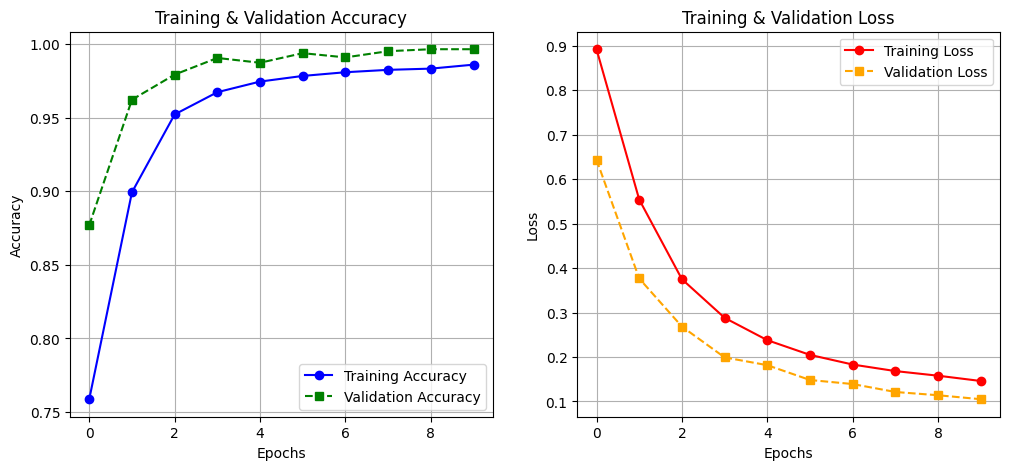

In [48]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy", color="blue", marker="o", linestyle="-")
plt.plot(epochs_range, val_acc, label="Validation Accuracy", color="green", marker="s", linestyle="--")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss", color="red", marker="o", linestyle="-")
plt.plot(epochs_range, val_loss, label="Validation Loss", color="orange", marker="s", linestyle="--")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Drowsy Selfie - Predicted Class: Drowsy, Confidence: 1.0000
Non-Drowsy Selfie - Predicted Class: Drowsy, Confidence: 1.0000


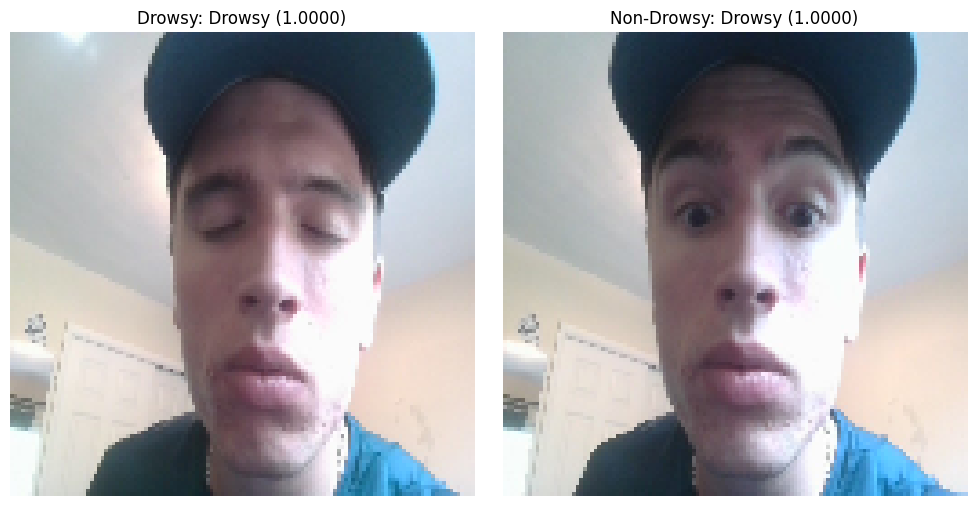

In [57]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

drowsy_selfie = '../data/drowsy2_selfie.jpg'
nondrowsy_selfie = '../data/nondrowsy2_selfie.jpg'

def preprocess_image(image_path):
    img = load_img(image_path, target_size=(128, 128))
    img_array = img_to_array(img)
    img_array = img_array / 255.0 
    img_array = np.expand_dims(img_array, axis=0)
    return img, img_array

drowsy_img, drowsy_array = preprocess_image(drowsy_selfie)
nondrowsy_img, nondrowsy_array = preprocess_image(nondrowsy_selfie)

drowsy_pred = model.predict(drowsy_array)[0][0]
nondrowsy_pred = model.predict(nondrowsy_array)[0][0]

class_indices = test_batches.class_indices
class_names = {v: k for k, v in class_indices.items()}

drowsy_class = 1 if drowsy_pred > 0.5 else 0
drowsy_label = class_names[drowsy_class]
drowsy_confidence = drowsy_pred if drowsy_class == 1 else 1 - drowsy_pred
nondrowsy_class = 1 if nondrowsy_pred > 0.5 else 0
nondrowsy_label = class_names[nondrowsy_class]
nondrowsy_confidence = nondrowsy_pred if nondrowsy_class == 1 else 1 - nondrowsy_pred

print(f"Drowsy Selfie - Predicted Class: {drowsy_label}, Confidence: {drowsy_confidence:.4f}")
print(f"Non-Drowsy Selfie - Predicted Class: {nondrowsy_label}, Confidence: {nondrowsy_confidence:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(drowsy_img)
ax1.set_title(f"Drowsy: {drowsy_label} ({drowsy_confidence:.4f})")
ax1.axis('off')
ax2.imshow(nondrowsy_img)
ax2.set_title(f"Non-Drowsy: {nondrowsy_label} ({nondrowsy_confidence:.4f})")
ax2.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


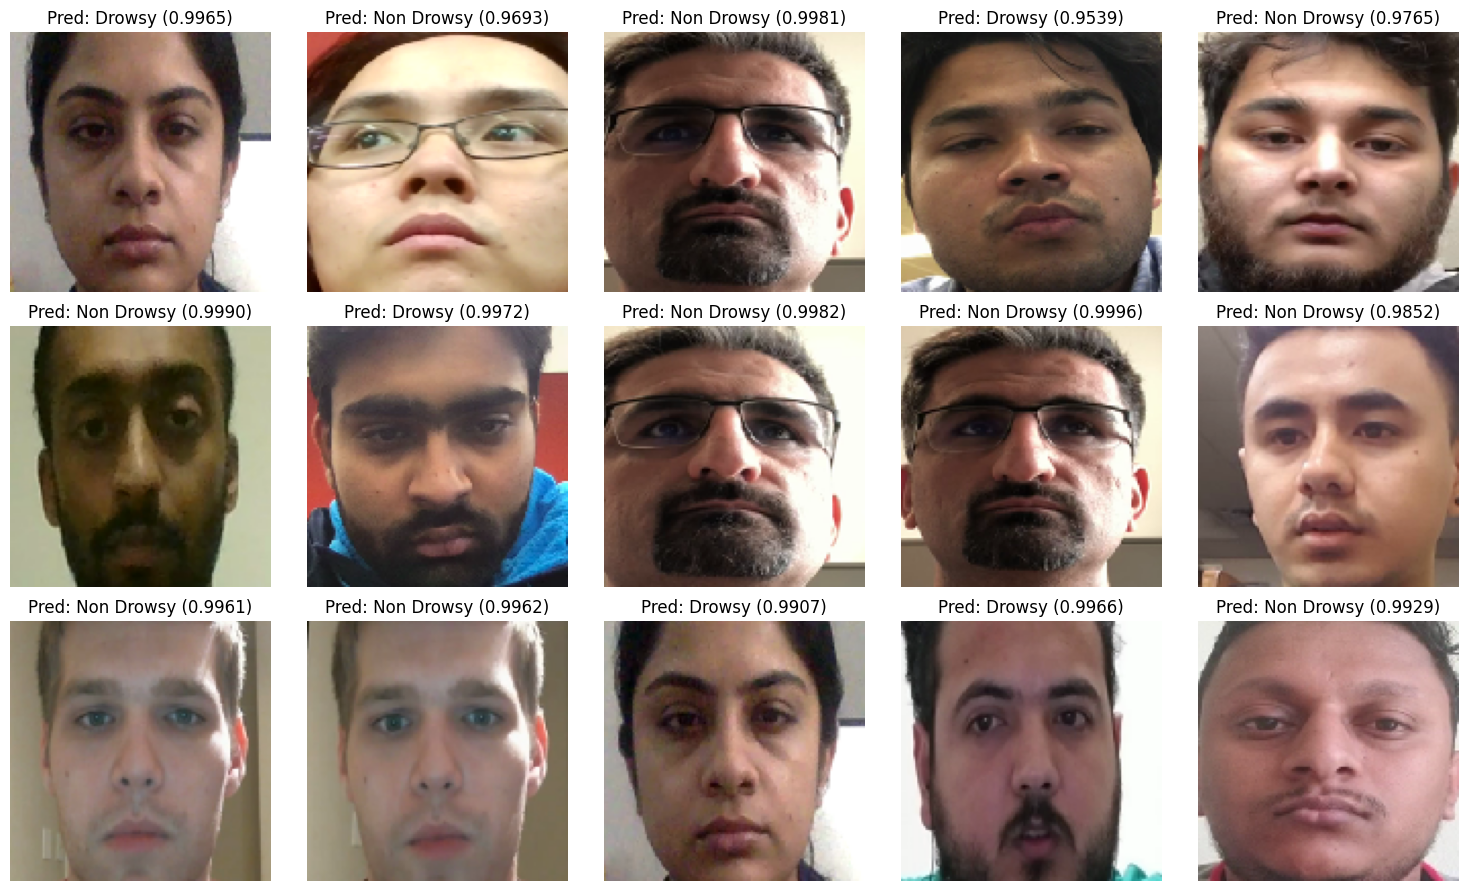

Predictions for displayed images:
Image 1: Predicted Class: Drowsy, Confidence: 0.9965
Image 2: Predicted Class: Non Drowsy, Confidence: 0.9693
Image 3: Predicted Class: Non Drowsy, Confidence: 0.9981
Image 4: Predicted Class: Drowsy, Confidence: 0.9539
Image 5: Predicted Class: Non Drowsy, Confidence: 0.9765
Image 6: Predicted Class: Non Drowsy, Confidence: 0.9990
Image 7: Predicted Class: Drowsy, Confidence: 0.9972
Image 8: Predicted Class: Non Drowsy, Confidence: 0.9982
Image 9: Predicted Class: Non Drowsy, Confidence: 0.9996
Image 10: Predicted Class: Non Drowsy, Confidence: 0.9852
Image 11: Predicted Class: Non Drowsy, Confidence: 0.9961
Image 12: Predicted Class: Non Drowsy, Confidence: 0.9962
Image 13: Predicted Class: Drowsy, Confidence: 0.9907
Image 14: Predicted Class: Drowsy, Confidence: 0.9966
Image 15: Predicted Class: Non Drowsy, Confidence: 0.9929


In [56]:
num_images = 15

test_batches.reset()
images, true_labels = next(test_batches)

images = images[:num_images]
true_labels = true_labels[:num_images]

predictions = model.predict(images)

class_indices = test_batches.class_indices
class_names = {v: k for k, v in class_indices.items()}

rows = (num_images + 4) // 5
cols = min(num_images, 5)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten() if num_images > 1 else [axes]

for i in range(num_images):
    img = images[i]
    pred_prob = predictions[i][0]
    pred_class = 1 if pred_prob > 0.5 else 0
    pred_label = class_names[pred_class]
    confidence = pred_prob if pred_class == 1 else 1 - pred_prob
    

    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {pred_label} ({confidence:.4f})")
    axes[i].axis('off')


for i in range(num_images, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("Predictions for displayed images:")
for i in range(num_images):
    pred_prob = predictions[i][0]
    pred_class = 1 if pred_prob > 0.5 else 0
    pred_label = class_names[pred_class]
    confidence = pred_prob if pred_class == 1 else 1 - pred_prob
    print(f"Image {i+1}: Predicted Class: {pred_label}, Confidence: {confidence:.4f}")